In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")


#style
sns.set_theme(style= "whitegrid")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.family"] = "DejaVu Sans"

#paths
BASE_DIR   = os.path.expanduser("~/superstore-sales-analysis")
DATA_PATH  = os.path.join(BASE_DIR, "data", "superstore_clean.csv")
CHART_DIR  = os.path.join(BASE_DIR, "outputs", "charts")

#load
df = pd.read_csv(DATA_PATH, parse_dates=["order_date"])
print(f"✅ loaded: {df.shape[0]:,} rows * {df.shape[1]} columns")
df.head(3)

✅ loaded: 9,994 rows * 27 columns


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,postal_code,...,discount,profit,order_year,order_month,order_month_name,order_quarter,shipping_days,profit_margin,revenue_per_unit,is_unprofitable
0,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,...,0.0,41.91,2016,11,Nov,Q4,3,0.1600,130.98,False
1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,Henderson,Kentucky,42420,...,0.0,219.58,2016,11,Nov,Q4,3,0.3000,243.98,False
2,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,Los Angeles,California,90036,...,0.0,6.87,2016,6,Jun,Q2,4,0.4699,7.31,False


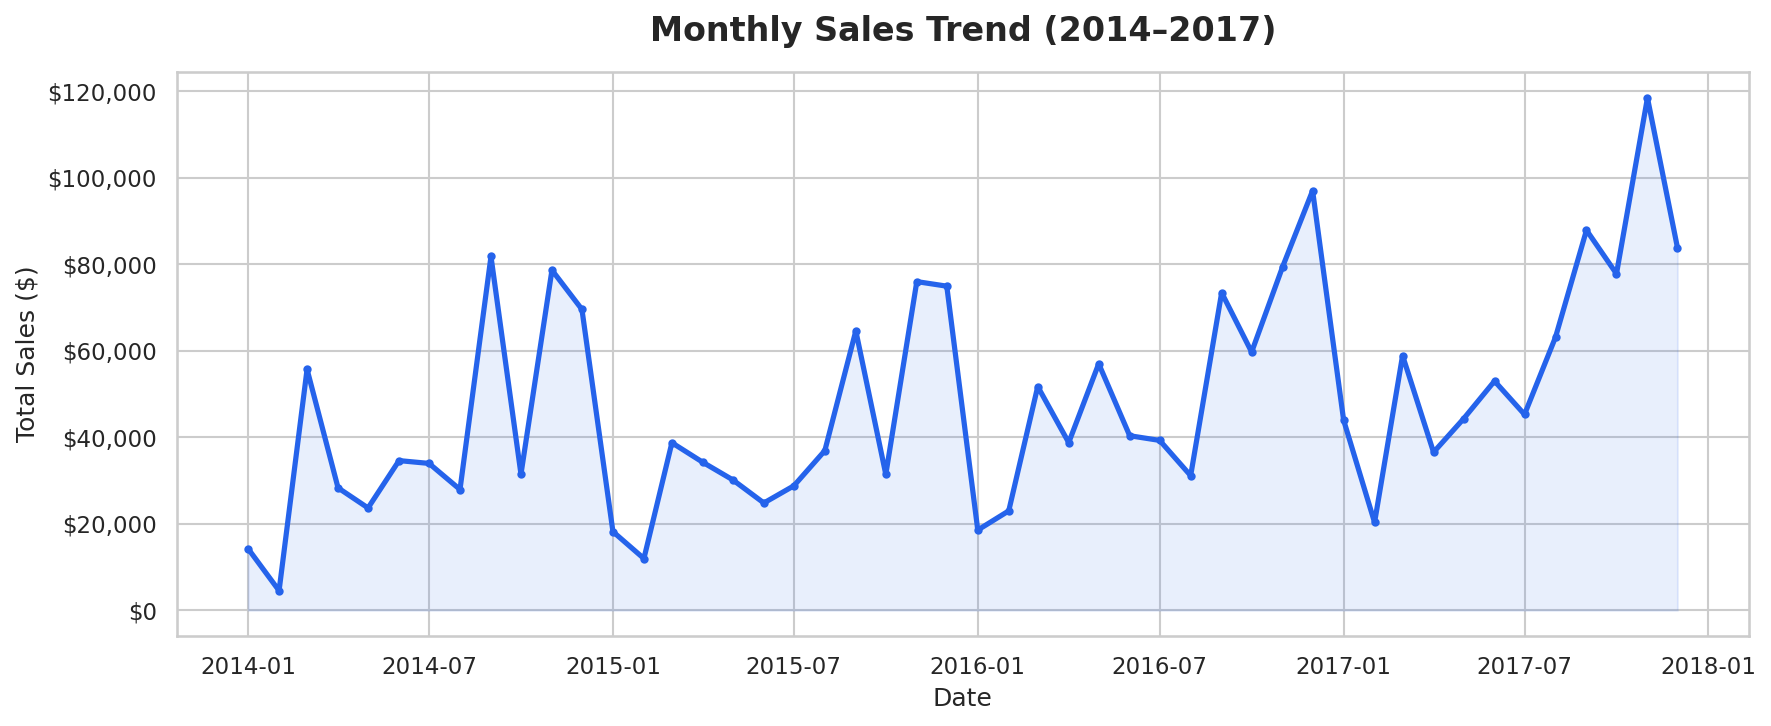

✅ Chart saved


In [23]:
# Cell 2 — Sales Trend Over Time (Line Chart)
monthly_sales = (
    df.groupby(["order_year", "order_month"])["sales"]
    .sum()
    .reset_index()
)
monthly_sales["date"] = pd.to_datetime(
    monthly_sales["order_year"].astype(str) + "-" +
    monthly_sales["order_month"].astype(str) + "-01"
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(monthly_sales["date"], monthly_sales["sales"],
        color="#2563EB", linewidth=2.5, marker="o", markersize=3)

ax.fill_between(monthly_sales["date"], monthly_sales["sales"],
                alpha=0.1, color="#2563EB")

ax.set_title("Monthly Sales Trend (2014–2017)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Total Sales ($)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "01_sales_trend.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

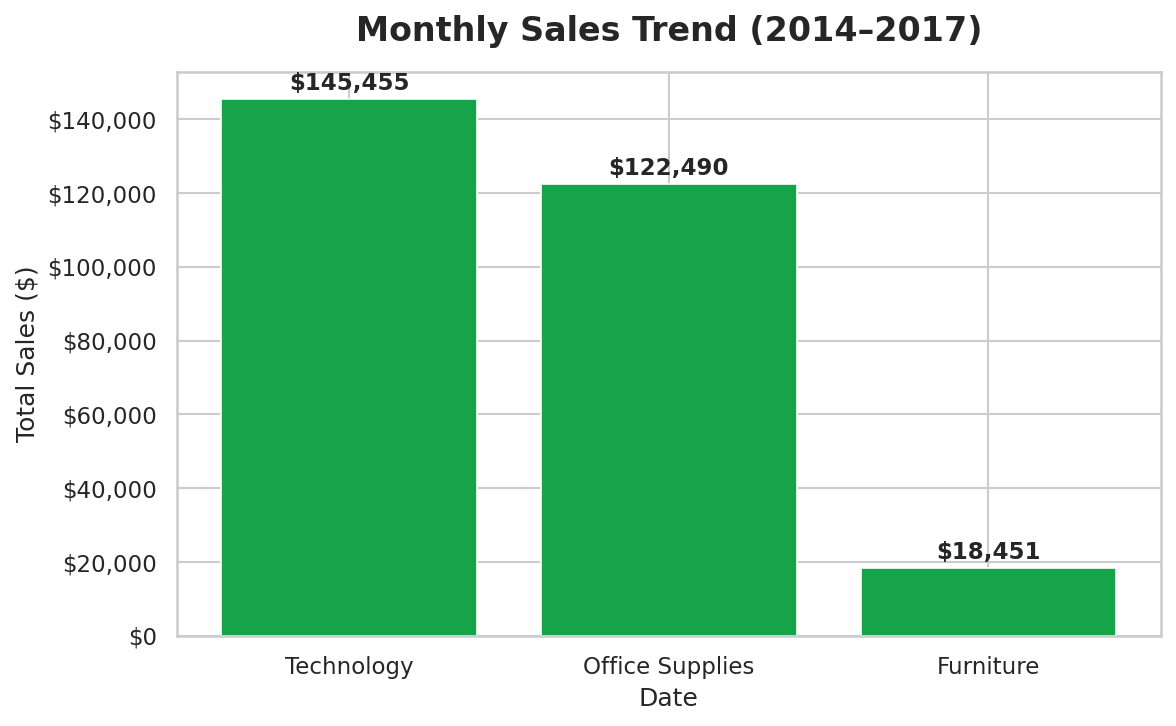

✅ Chart saved


In [32]:
#Profit by Category (Bar Chart)
category_profit = (
    df.groupby("category")["profit"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
colors = ["#16A34A" if x > 0 else "#DC2626" for x in category_profit["profit"]]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(category_profit["category"], category_profit["profit"],
              color=colors, edgecolor="white", linewidth=0.8)

#add value labels on bars
for bar, val in zip(bars, category_profit["profit"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1000,
            f"${val:,.0f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Monthly Sales Trend (2014–2017)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Total Sales ($)", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))


plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "02_profit_by_category.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")


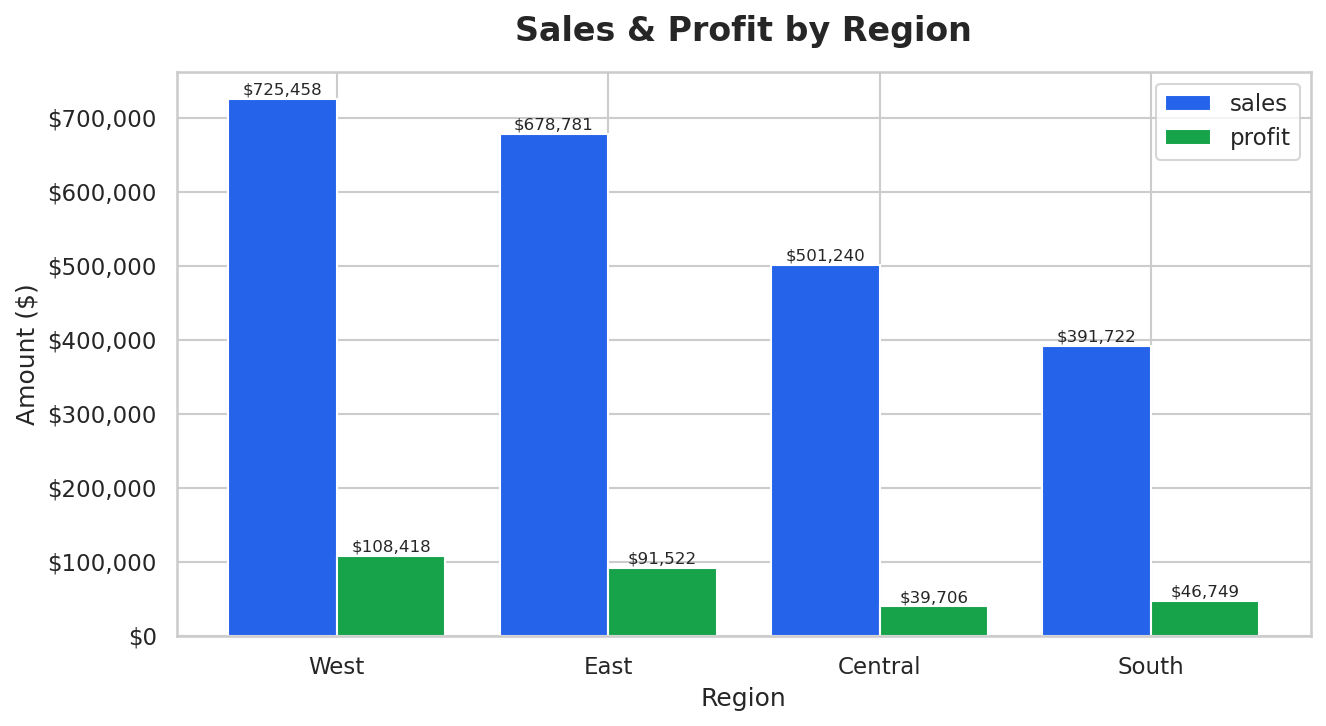

✅ Chart saved


In [37]:
#sales & profit by region (Bar Chart)
region_data = (
    df.groupby("region")[["sales" , "profit"]]
    .sum()
    .sort_values("sales", ascending=False)
    .reset_index()
)

x = range(len(region_data))
width= 0.4

fig, ax = plt.subplots(figsize=(9,5))

bars1 = ax.bar([i - width/2 for i in x], region_data["sales"], 
               width=width, label="sales", color="#2563EB", edgecolor="white")

bars2 = ax.bar([i + width/2 for i in x], region_data["profit"],
               width=width, label="profit", color="#16A34A", edgecolor="white")


#value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2000,
            f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"${bar.get_height():,.0f}", ha="center", va="bottom", fontsize=8)


ax.set_title("Sales & Profit by Region", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Region", fontsize=12)
ax.set_ylabel("Amount ($)", fontsize=12)
ax.set_xticks(list(x))
ax.set_xticklabels(region_data["region"], fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "03_sales_by_region.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")

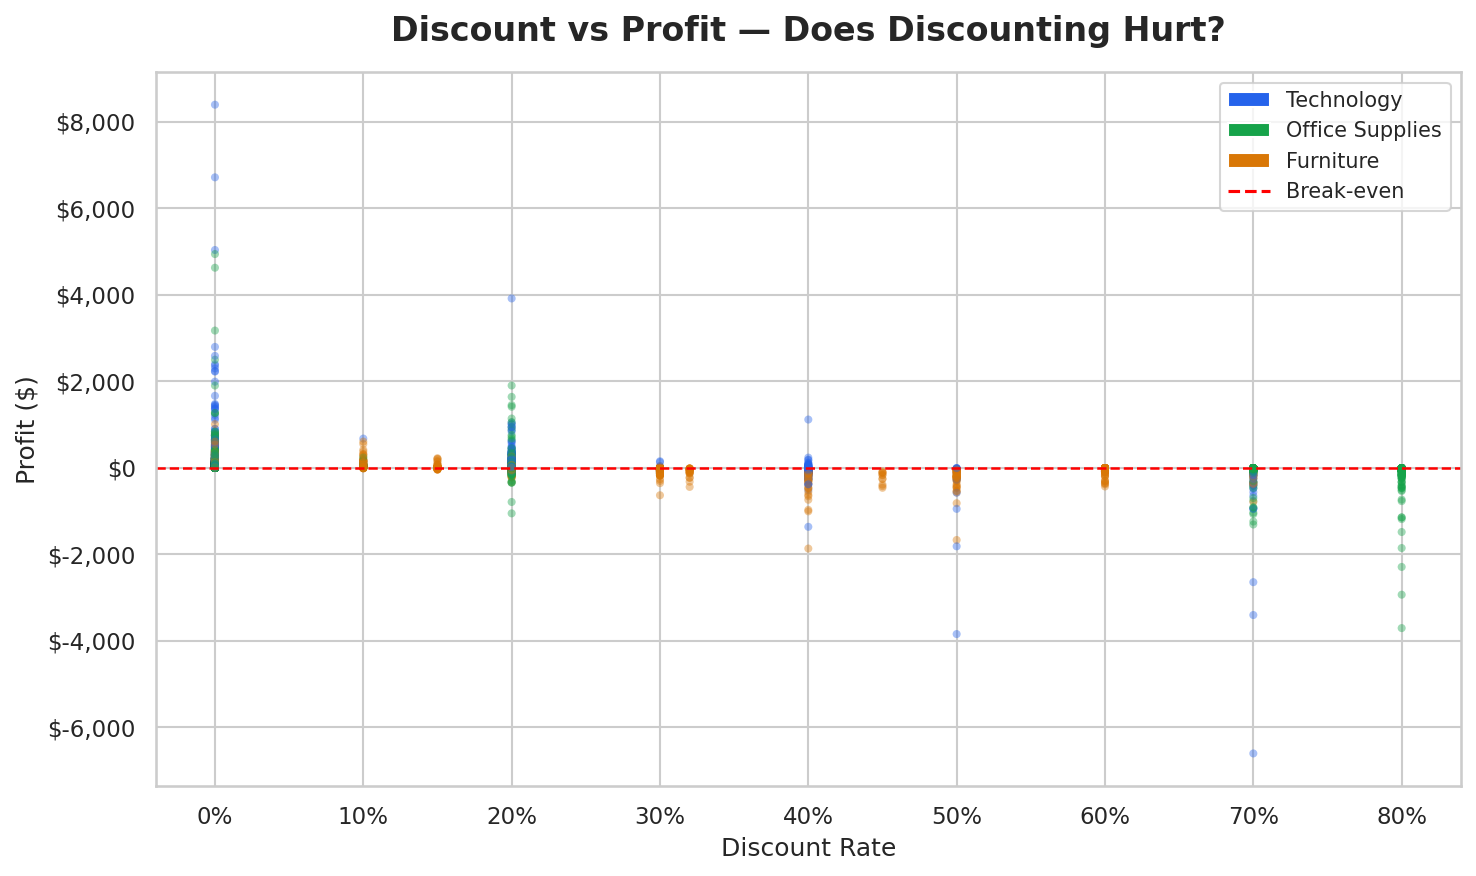

✅ Chart saved


In [42]:
#discount vs profit
fig, ax = plt.subplots(figsize=(10,6))

colors = df["category"].map({
    "Technology": "#2563EB",
    "Office Supplies": "#16A34A",
    "Furniture": "#D97706"
})

ax.scatter(df["discount"], df["profit"],
           c=colors, alpha=0.4, s=15, edgecolors="none")

#Refrence line at profit = 0
ax.axhline(y=0, color="red", linestyle="--", linewidth=1.2, label="break-even")

#legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2563EB", label="Technology"),
    Patch(facecolor="#16A34A", label="Office Supplies"),
    Patch(facecolor="#D97706", label="Furniture"),
    plt.Line2D([0], [0], color="red", linestyle="--", label="Break-even")
]
ax.legend(handles=legend_elements, fontsize=10)

ax.set_title("Discount vs Profit — Does Discounting Hurt?", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Discount Rate", fontsize=12)
ax.set_ylabel("Profit ($)", fontsize=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "04_discount_vs_profit.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")



    

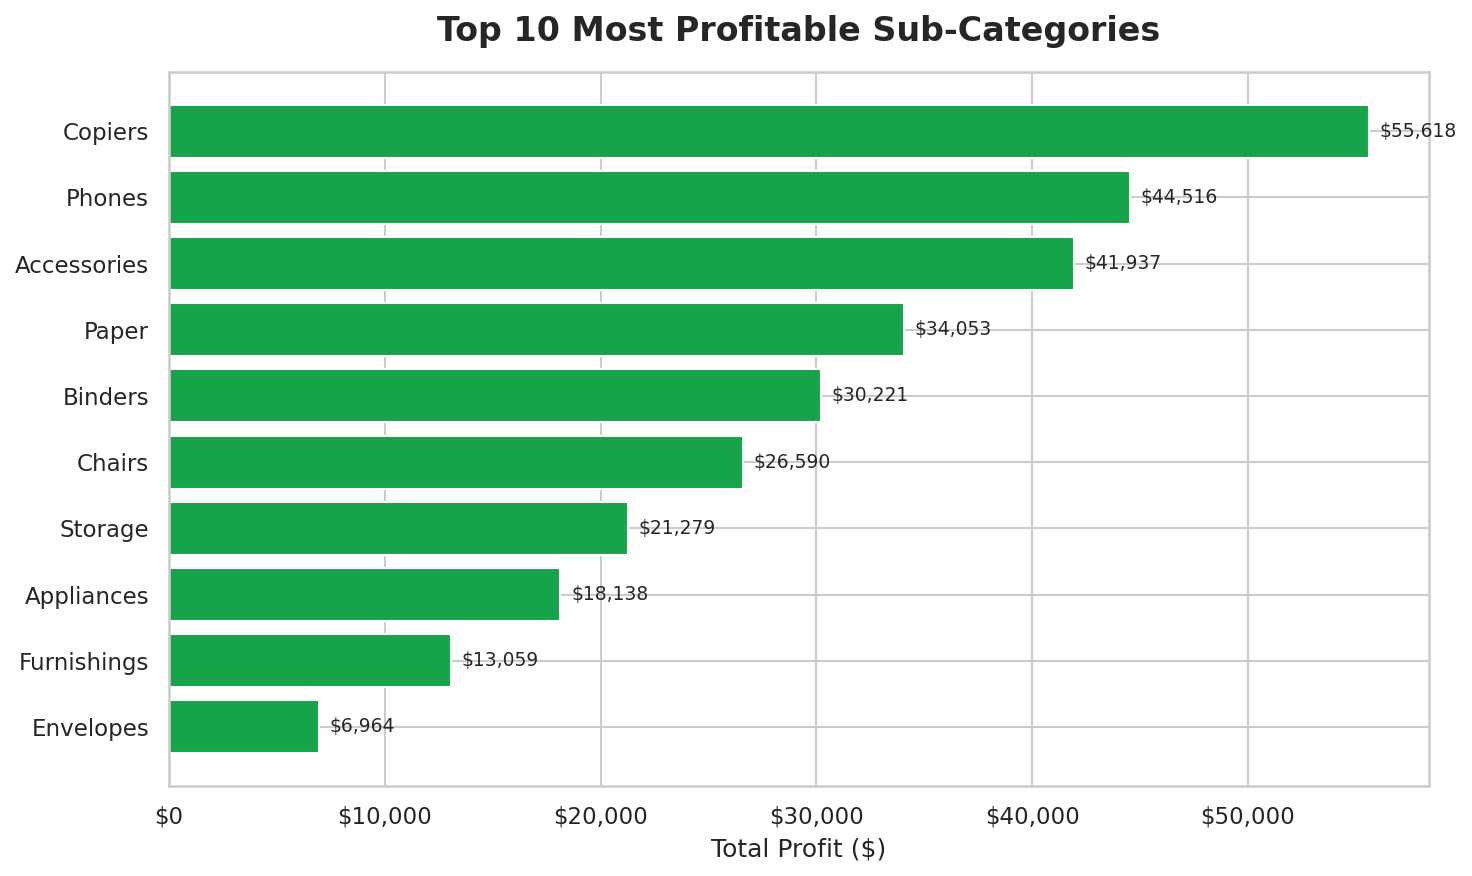

✅ Chart Saved


In [48]:
#Top 10 Most Profitable Sub-Categories (Horizontal Bar)
sub_profit = (
    df.groupby("sub_category")["profit"]
    .sum()
    .sort_values()
    .tail(10)
    .reset_index()
)

colors = ["#16A34A" if x > 0 else "#DC2626" for x in sub_profit["profit"]]
fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(sub_profit["sub_category"], sub_profit["profit"],
               color=colors, edgecolor="white")

#value_label
for bar, val in zip(bars, sub_profit["profit"]):
    ax.text(bar.get_width()+500, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", fontsize=9)

ax.set_title("Top 10 Most Profitable Sub-Categories", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Total Profit ($)", fontsize=12)
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.axvline(x=0, color="black", linewidth=0.8)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "05_top_subcategories.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart Saved")


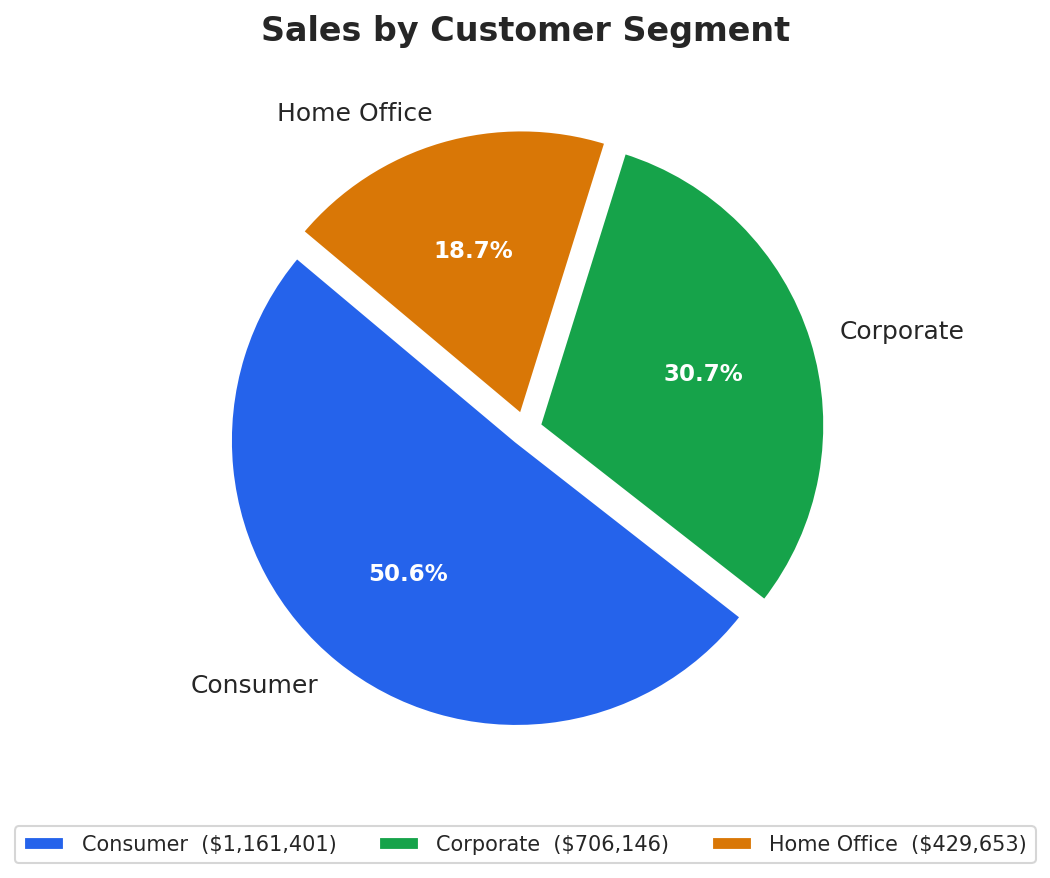

✅ Chart saved


In [50]:
#Sales by Customer Segment (Pie Chart):
segment_sales = (
    df.groupby("segment")["sales"]
    .sum()
    .sort_values(ascending=False)
)

colors = ["#2563EB", "#16A34A", "#D97706"]
explode = (0.05, 0.05, 0.05)

fig, ax = plt.subplots(figsize=(8,6))

wedges, texts, autotexts = ax.pie(
    segment_sales, 
    labels=segment_sales.index,
    autopct="%1.1f%%", 
    colors = colors,
    explode=explode,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

# Add dollar values in legend
legend_labels = [f"{seg}  (${val:,.0f})"
                 for seg, val in zip(segment_sales.index, segment_sales.values)]
ax.legend(wedges, legend_labels, loc="lower center",
          bbox_to_anchor=(0.5, -0.12), fontsize=10, ncol=3)

ax.set_title("Sales by Customer Segment", fontsize=16, fontweight="bold", pad=15)

plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR, "06_sales_by_segment.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved")